# TB-DOTS CAR CDSS — Random Forest Treatment Outcome Prediction

This notebook trains a **Random Forest** classifier for predicting TB treatment outcome (**Success / Failure**) using monthly patient monitoring data and baseline clinical features.

### Class Imbalance Handling
To address the severe class imbalance (~90% Success / ~10% Failure):
- **SMOTE-ENN** (Synthetic Minority Oversampling + Edited Nearest Neighbors) — generates synthetic Failure samples then removes noisy/misclassified samples via ENN cleaning
- **`class_weight='balanced'`** — automatically adjusts weights inversely proportional to class frequencies
- **Threshold optimization** — finds optimal classification threshold on validation set

### Progressive Temporal Prediction
Each model supports **prediction at any month** (M0–M12). For each month `t`, features include:
- **Static features** (51 baseline clinical features)
- **Temporal features up to month t** (flattened + aggregates + trends)

### Outputs
- Trained model checkpoint → `models/Temporal/output/random_forest/rf_smoteenn_model.pkl`
- Evaluation report → `models/Temporal/output/random_forest/rf_evaluation_report.txt`
- Feature importance → `models/Temporal/output/random_forest/rf_feature_importance.png`
- Per-month performance → `models/Temporal/output/random_forest/rf_per_month_performance.png`
- Metrics/config files → `models/Temporal/output/random_forest/`


## 0. Imports & Configuration

In [1]:
import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Paths ───────────────────────────────────────────────────────
REPO_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "dataset").exists() and (p / "models").exists()),
    Path.cwd(),
)
BASE_DIR = REPO_ROOT
DATA_DIR = REPO_ROOT / "dataset" / "temporal"
MODEL_DIR = REPO_ROOT / "models" / "Temporal" / "v2" / "output" / "random_forest"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data    : {DATA_DIR}")
print(f"Models  : {MODEL_DIR}")


Data    : c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\dataset\temporal
Models  : c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\models\Temporal\v2\output\random_forest


## 1. Data Loading & Label Creation

Load the same preprocessed temporal and static arrays. Outcome columns are removed from static features to prevent target leakage. Binary labels:
- **Success (1)** = Cured, Treatment Completed
- **Failure (0)** = Died, Lost to Follow-Up, Not Evaluated

In [2]:
def load_data():
    """Load harmonized temporal data with trustworthy train-fit transforms."""
    import sys
    sys.path.append(str(BASE_DIR / "models" / "Temporal"))
    import model_utils as mu

    csv_path = DATA_DIR / "output" / "cleaned_human_readable.csv"
    model_data = mu.prepare_default_model_inputs(
        str(csv_path),
        train_frac=0.70,
        val_frac=0.20,
        test_frac=0.10,
        random_state=SEED,
        drop_feature_cols=mu.get_temporal_v2_drop_feature_cols(),
    )

    X_temporal = model_data["X_temporal"]
    X_static = model_data["X_static"]
    y = model_data["y"]
    static_names = list(model_data["static_feature_names"])
    temporal_names = list(model_data["temporal_feature_names"])
    train_idx = model_data["train_idx"]
    val_idx = model_data["val_idx"]
    test_idx = model_data["test_idx"]
    df = model_data["df"]
    global FEATURE_POLICY_VERSION, DROPPED_FEATURE_COLS, STATIC_MNAR_INDICATORS, TEMPORAL_MNAR_INDICATORS, TEMPORAL_FEATURE_NAMES
    FEATURE_POLICY_VERSION = model_data.get("feature_policy_version", "custom")
    DROPPED_FEATURE_COLS = model_data.get("dropped_feature_cols", [])
    STATIC_MNAR_INDICATORS = model_data.get("static_missing_indicator_names", [])
    TEMPORAL_MNAR_INDICATORS = model_data.get("temporal_missing_indicator_names", [])
    TEMPORAL_FEATURE_NAMES = list(model_data["temporal_feature_names"])

    print(f"Temporal features : {X_temporal.shape}")
    print(f"Static features   : {X_static.shape}  (leakage-controlled + MNAR-aware)")
    print(f"Feature policy    : {model_data.get('feature_policy_version', 'custom')}")
    print(f"Dropped features  : {model_data.get('dropped_feature_cols', [])}")
    print(f"Static MNAR flags : {len(model_data.get('static_missing_indicator_names', []))}")
    print(f"Temporal MNAR flags: {len(model_data.get('temporal_missing_indicator_names', []))}")
    print(f"Labels            : {y.shape}  (Success={int(y.sum())}, Failure={int(len(y) - y.sum())})")
    print(f"Split sizes       : train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")

    return X_temporal, X_static, y, static_names, temporal_names, df, train_idx, val_idx, test_idx


X_temporal, X_static, y, static_names, temporal_names, df, train_idx, val_idx, test_idx = load_data()


STAGE 3: Data Cleaning & Type Coercion
  Parsed 'date_of_birth': 431/431 valid dates
  Parsed 'date_of_diagnosis': 431/431 valid dates
  Parsed 'date_of_notification': 431/431 valid dates
  Parsed 'treatment_start_date': 431/431 valid dates
  Parsed 'date_of_outcome': 431/431 valid dates
  Parsed 'intensive_phase_start_date': 431/431 valid dates
  Parsed 'intensive_phase_end_date': 431/431 valid dates
  Parsed 'continuation_phase_start_date': 431/431 valid dates
  Parsed 'continuation_phase_end_date': 431/431 valid dates
  Fixed 1 rows where treatment_start_date < date_of_diagnosis (set to date_of_diagnosis)
  Parsed 'weight' -> 'weight_kg': 431 valid (raw 'weight' standardized to 'XX.X kg')
  Parsed 'height' -> 'height_cm': 431 valid (raw 'height' standardized to 'XXX.X cm')
  Parsed 'o2_sat': 431 valid
  Parsed 'xpert_mtb_rif' -> binary: 431 valid
  Parsed 'smear_microscopy' -> binary: 431 valid
  Cleaned monthly columns M0-M12 (weight, height, adherence, smear, xpert, doses)

  --- 

## 2. Feature Engineering

Transform 3D temporal data into flat 2D features for Random Forest. For month `t`, features include:
- **Static baseline features** (51 features)
- **Raw temporal values** (flattened M0..Mt)
- **Aggregates** (mean, std, min, max)
- **Trends** (linear slopes)
- **Latest month values**

In [3]:
def build_features_at_month(X_temporal, X_static, up_to_month, temporal_names, static_names):
    """
    Build a flat feature matrix using data up to `up_to_month`.

    Features include:
    1. Static baseline features (always the same)
    2. Flattened raw temporal features up to month t
    3. Aggregate stats (mean, std, min, max) over available months
    4. Trend (linear slope) of key features
    5. Latest month's values
    6. Month indicator (how much data is available)

    Returns: X_flat (n_patients, n_features), feature_name_list
    """
    n_patients = X_temporal.shape[0]
    n_temporal_feats = X_temporal.shape[2]  # 8
    valid_months = up_to_month + 1

    feature_list = []
    feature_name_list = []

    # 1. Static features (always included)
    feature_list.append(X_static)
    feature_name_list.extend(static_names)

    # 2. Flattened temporal features for months 0..up_to_month
    temporal_flat = X_temporal[:, :valid_months, :].reshape(n_patients, -1)
    for m in range(valid_months):
        for feat in temporal_names:
            feature_name_list.append(f"M{m}_{feat}")
    feature_list.append(temporal_flat)

    # 3. Aggregate statistics over available months
    temporal_slice = X_temporal[:, :valid_months, :]  # (N, valid_months, 8)
    for agg_name, agg_fn in [("mean", np.mean), ("std", np.std),
                              ("min", np.min), ("max", np.max)]:
        agg = agg_fn(temporal_slice, axis=1)  # (N, 8)
        feature_list.append(agg)
        for feat in temporal_names:
            feature_name_list.append(f"{agg_name}_{feat}")

    # 4. Trend features (linear slope) for key temporal features
    if valid_months >= 2:
        slopes = np.zeros((n_patients, n_temporal_feats))
        x_time = np.arange(valid_months, dtype=np.float32)
        for i in range(n_patients):
            for j in range(n_temporal_feats):
                vals = temporal_slice[i, :, j]
                if np.std(vals) > 1e-8:
                    slope = np.polyfit(x_time, vals, 1)[0]
                else:
                    slope = 0.0
                slopes[i, j] = slope
        feature_list.append(slopes)
        for feat in temporal_names:
            feature_name_list.append(f"trend_{feat}")
    else:
        # With only M0, slope is 0
        feature_list.append(np.zeros((n_patients, n_temporal_feats)))
        for feat in temporal_names:
            feature_name_list.append(f"trend_{feat}")

    # 5. Latest month's values
    latest = X_temporal[:, up_to_month, :]  # (N, 8)
    feature_list.append(latest)
    for feat in temporal_names:
        feature_name_list.append(f"latest_{feat}")

    # 6. Month indicator
    month_indicator = np.full((n_patients, 1), up_to_month, dtype=np.float32)
    feature_list.append(month_indicator)
    feature_name_list.append("months_available")

    X_flat = np.hstack(feature_list).astype(np.float32)
    # Replace any NaN from std calculations (single-month std = nan)
    X_flat = np.nan_to_num(X_flat, nan=0.0)

    return X_flat, feature_name_list


# Demo: build features at M12 (full data) to check dimensions
X_full, feat_names_full = build_features_at_month(
    X_temporal, X_static, up_to_month=12,
    temporal_names=temporal_names, static_names=static_names
)
print(f"Full feature matrix (M12): {X_full.shape}")
print(f"Number of features: {len(feat_names_full)}")

Full feature matrix (M12): (431, 399)
Number of features: 399


## 3. Patient-Level Train/Val/Test Split

Same 70/20/10 patient-level split as the other models (same random seed) for fair comparison.

In [4]:
print("Patient split (precomputed, patient-level stratified):")
for name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    yi = y[idx]
    print(f"  {name:>5s}: {len(idx)} patients  (Success={int(yi.sum())}, Failure={int(len(yi) - yi.sum())})")


Patient split (precomputed, patient-level stratified):
  Train: 301 patients  (Success=257, Failure=44)
    Val: 86 patients  (Success=73, Failure=13)
   Test: 44 patients  (Success=38, Failure=6)


## 4. Random Forest Training with SMOTE-ENN

Train Random Forest with **progressive temporal data** and **SMOTE-ENN** augmentation.

### SMOTE-ENN Pipeline
1. **SMOTE** — generates synthetic minority (Failure) samples in feature space
2. **Edited Nearest Neighbors (ENN)** — removes noisy/borderline samples whose class label disagrees with the majority of their k-nearest neighbors

This two-step approach produces cleaner training data than SMOTE alone.

### Hyperparameters
- `n_estimators=500`, `max_depth=8` (moderate depth for 205 patients)
- `class_weight='balanced'` — native class reweighting
- `oob_score=True` — out-of-bag estimate for generalization

In [5]:
import sys
sys.path.append(str(BASE_DIR / "models" / "Temporal"))
import model_utils as mu

scaled = mu.scale_full_arrays(X_static, X_temporal, train_idx)
X_static = scaled["X_static_scaled"]
X_temporal = scaled["X_temporal_scaled"]
mu.save_scalers(scaled["scaler_static"], scaled["scaler_temporal"], str(DATA_DIR))

print(f"Scaled arrays: X_temporal={X_temporal.shape}, X_static={X_static.shape}")
print(f"Split sizes: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")

Scaled arrays: X_temporal=(431, 13, 16), X_static=(431, 94)
Split sizes: train=301, val=86, test=44


In [6]:
def train_random_forest(X_temporal, X_static, y, train_idx, val_idx,
                        temporal_names, static_names,
                        save_name="rf_smoteenn_model.pkl"):
    """
    Train Random Forest with progressive temporal data and SMOTE-ENN.
    """
    # Build full-length (M12) features
    X_train_full, feat_names = build_features_at_month(
        X_temporal[train_idx], X_static[train_idx],
        up_to_month=12,
        temporal_names=temporal_names,
        static_names=static_names,
    )

    X_val_full, _ = build_features_at_month(
        X_temporal[val_idx], X_static[val_idx],
        up_to_month=12,
        temporal_names=temporal_names,
        static_names=static_names,
    )
    y_val = y[val_idx]

    # Progressive training data (M0–M12 for each patient)
    X_train_prog = []
    y_train_prog = []
    for month in range(13):
        X_m, _ = build_features_at_month(
            X_temporal[train_idx], X_static[train_idx],
            up_to_month=month,
            temporal_names=temporal_names,
            static_names=static_names,
        )
        if X_m.shape[1] < X_train_full.shape[1]:
            pad_width = X_train_full.shape[1] - X_m.shape[1]
            X_m = np.hstack([X_m, np.zeros((X_m.shape[0], pad_width), dtype=np.float32)])
        X_train_prog.append(X_m)
        y_train_prog.append(y[train_idx])

    X_train_all = np.vstack(X_train_prog)
    y_train_all = np.concatenate(y_train_prog)

    print(f"\n{'='*55}")
    print(f"  Random Forest + SMOTE-ENN")
    print(f"{'='*55}")
    print(f"Progressive training samples: {X_train_all.shape[0]} "
          f"({len(train_idx)} patients × 13 months)")
    print(f"Feature dimensions: {X_train_all.shape[1]}")

    # ── Apply SMOTE-ENN ─────────────────────────────────────────
    n_minority = int((y_train_all == 0).sum())
    n_majority = int((y_train_all == 1).sum())
    print(f"\nBefore SMOTE-ENN: Success={n_majority}, Failure={n_minority}")

    k = min(5, n_minority - 1)
    if k >= 1:
        smote_enn = SMOTEENN(
            smote=SMOTE(random_state=SEED, k_neighbors=k),
            random_state=SEED,
        )
        X_train_all, y_train_all = smote_enn.fit_resample(X_train_all, y_train_all)

        n_minority_after = int((y_train_all == 0).sum())
        n_majority_after = int((y_train_all == 1).sum())
        print(f"After SMOTE-ENN:  Success={n_majority_after}, Failure={n_minority_after}")
        print(f"Total training samples: {len(y_train_all)} "
              f"(ENN removed noisy samples after SMOTE oversampling)")
    else:
        print(f"SMOTE-ENN skipped: not enough minority samples (k_neighbors={k})")

    # ── Train Random Forest ─────────────────────────────────────
    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
        oob_score=True,
    )
    model.fit(X_train_all, y_train_all)

    # Save model
    joblib.dump(model, MODEL_DIR / save_name)
    print(f"\nOOB Score: {model.oob_score_:.4f}")
    print(f"Model saved to models/{save_name}")

    return model, feat_names


# ── Train ────────────────────────────────────────────────────────
rf_model, feature_names_rf = train_random_forest(
    X_temporal, X_static, y, train_idx, val_idx,
    temporal_names, static_names,
    save_name="rf_smoteenn_model.pkl",
)


  Random Forest + SMOTE-ENN
Progressive training samples: 3913 (301 patients × 13 months)
Feature dimensions: 399

Before SMOTE-ENN: Success=3341, Failure=572


  File "c:\Users\Ven\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Ven\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Ven\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Ven\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                    

After SMOTE-ENN:  Success=2755, Failure=3313
Total training samples: 6068 (ENN removed noisy samples after SMOTE oversampling)

OOB Score: 0.9726
Model saved to models/rf_smoteenn_model.pkl


## 5. Evaluation

Evaluate on the held-out **10% test set** using full M0–M12 data, with **optimized classification threshold** from validation set.

In [7]:
def predict_at_month(model, X_temporal_subset, X_static_subset,
                     up_to_month, temporal_names, static_names,
                     n_features_full):
    """
    Generate predictions using data up to a specific month.
    Pads feature vector to match the full M12 width the model was trained on.
    """
    X_month, _ = build_features_at_month(
        X_temporal_subset, X_static_subset,
        up_to_month=up_to_month,
        temporal_names=temporal_names,
        static_names=static_names,
    )
    if X_month.shape[1] < n_features_full:
        pad_width = n_features_full - X_month.shape[1]
        X_month = np.hstack([X_month, np.zeros((X_month.shape[0], pad_width),
                                                dtype=np.float32)])
    probs = model.predict_proba(X_month)[:, 1]
    return probs


def find_optimal_threshold(model, X_temporal, X_static, y, val_idx,
                           temporal_names, static_names, n_features_full):
    """
    Find the optimal classification threshold on the validation set.
    Prioritizes detecting treatment failures for medical risk prediction.
    """
    probs = predict_at_month(
        model, X_temporal[val_idx], X_static[val_idx],
        up_to_month=12,
        temporal_names=temporal_names,
        static_names=static_names,
        n_features_full=n_features_full,
    )
    labels = y[val_idx]

    best_score = 0
    best_thresh = 0.5
    thresholds = np.arange(0.1, 0.9, 0.01)

    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)
        failure_recall = recall_score(labels, preds, pos_label=0, zero_division=0)
        balanced_acc = balanced_accuracy_score(labels, preds)
        combined = failure_recall * 0.55 + balanced_acc * 0.25 + f1 * 0.20
        if combined > best_score:
            best_score = combined
            best_thresh = t

    return best_thresh


def evaluate_model(model, X_temporal, X_static, y, test_idx,
                   temporal_names, static_names, n_features_full,
                   threshold=0.5):
    """Full evaluation on held-out test set using M12 data."""
    probs = predict_at_month(
        model, X_temporal[test_idx], X_static[test_idx],
        up_to_month=12,
        temporal_names=temporal_names,
        static_names=static_names,
        n_features_full=n_features_full,
    )
    labels = y[test_idx]
    preds = (probs >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "specificity": recall_score(labels, preds, pos_label=0, zero_division=0),
    }
    try:
        metrics["roc_auc"] = roc_auc_score(labels, probs)
    except ValueError:
        metrics["roc_auc"] = float("nan")
    try:
        metrics["pr_auc"] = average_precision_score(labels, probs)
    except ValueError:
        metrics["pr_auc"] = float("nan")

    cm = confusion_matrix(labels, preds)
    return probs, preds, labels, metrics, cm


def evaluate_per_month(model, X_temporal_subset, X_static_subset,
                       y_subset, temporal_names, static_names,
                       n_features_full, threshold=0.5):
    """Evaluate model accuracy at each month (M0–M12) for test patients."""
    month_metrics = []
    for month in range(13):
        probs = predict_at_month(
            model, X_temporal_subset, X_static_subset,
            up_to_month=month,
            temporal_names=temporal_names,
            static_names=static_names,
            n_features_full=n_features_full,
        )
        preds = (probs >= threshold).astype(int)
        acc = accuracy_score(y_subset, preds)
        balanced_acc = balanced_accuracy_score(y_subset, preds)
        f1 = f1_score(y_subset, preds, zero_division=0)
        spec = recall_score(y_subset, preds, pos_label=0, zero_division=0)
        try:
            auc = roc_auc_score(y_subset, probs)
        except ValueError:
            auc = float("nan")

        month_metrics.append({
            "month": f"M{month}", "accuracy": acc,
            "f1": f1, "balanced_accuracy": balanced_acc, "specificity": spec, "auc": auc,
            "n_correct": int((preds == y_subset).sum()),
            "n_total": len(y_subset),
        })
    return pd.DataFrame(month_metrics)


# ── Feature count at M12 ────────────────────────────────────────
n_features_full = build_features_at_month(
    X_temporal[:1], X_static[:1], 12, temporal_names, static_names
)[0].shape[1]

# ── Evaluate ────────────────────────────────────────────────────
optimal_threshold = find_optimal_threshold(
    rf_model, X_temporal, X_static, y, val_idx,
    temporal_names, static_names, n_features_full
)
print(f"Optimal threshold: {optimal_threshold:.2f}")

rf_probs, rf_preds, rf_labels, rf_metrics, rf_cm = evaluate_model(
    rf_model, X_temporal, X_static, y, test_idx,
    temporal_names, static_names, n_features_full,
    threshold=optimal_threshold,
)

print(f"\n{'='*55}")
print(f"  Random Forest + SMOTE-ENN — Test Evaluation")
print(f"{'='*55}")
for k, v in rf_metrics.items():
    print(f"  {k:<14s} : {v:.4f}")
print(f"\nConfusion Matrix:\n{rf_cm}")
print(f"\n{classification_report(rf_labels, rf_preds, target_names=['Failure', 'Success'], zero_division=0)}")

Optimal threshold: 0.67

  Random Forest + SMOTE-ENN — Test Evaluation
  accuracy       : 0.9318
  balanced_accuracy : 0.8904
  precision      : 0.9730
  recall         : 0.9474
  f1             : 0.9600
  specificity    : 0.8333
  roc_auc        : 0.9693
  pr_auc         : 0.9950

Confusion Matrix:
[[ 5  1]
 [ 2 36]]

              precision    recall  f1-score   support

     Failure       0.71      0.83      0.77         6
     Success       0.97      0.95      0.96        38

    accuracy                           0.93        44
   macro avg       0.84      0.89      0.86        44
weighted avg       0.94      0.93      0.93        44



### Evaluation Plots

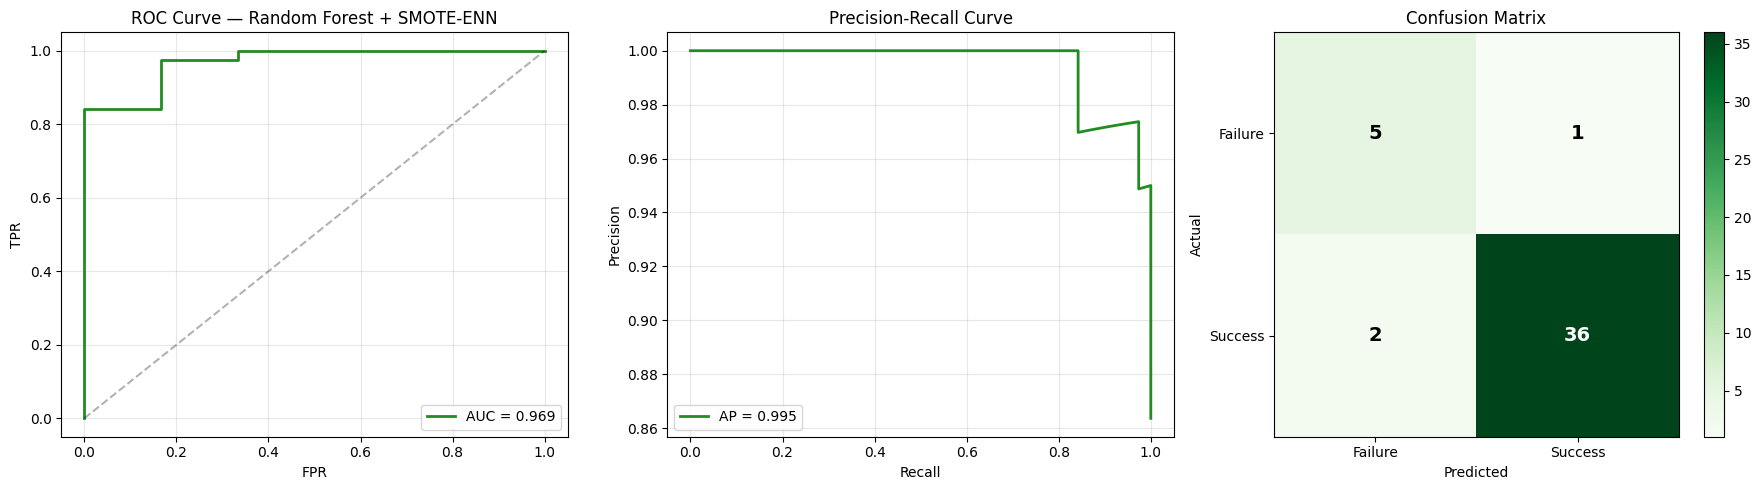

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
try:
    fpr, tpr, _ = roc_curve(rf_labels, rf_probs)
    auc_val = roc_auc_score(rf_labels, rf_probs)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.3f}", color="forestgreen")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
except ValueError:
    axes[0].text(0.5, 0.5, "Insufficient data", ha="center", va="center")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve — Random Forest + SMOTE-ENN")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PR Curve
try:
    prec, rec, _ = precision_recall_curve(rf_labels, rf_probs)
    ap = average_precision_score(rf_labels, rf_probs)
    axes[1].plot(rec, prec, linewidth=2, label=f"AP = {ap:.3f}", color="forestgreen")
except ValueError:
    axes[1].text(0.5, 0.5, "Insufficient data", ha="center", va="center")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion Matrix
im = axes[2].imshow(rf_cm, cmap="Greens", interpolation="nearest")
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(["Failure", "Success"])
axes[2].set_yticklabels(["Failure", "Success"])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(rf_cm[i][j]),
                     ha="center", va="center",
                     color="white" if rf_cm[i][j] > rf_cm.max() / 2 else "black",
                     fontsize=14, fontweight="bold")
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig(MODEL_DIR / "rf_evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Feature Importance

A key advantage of Random Forest — built-in **Gini importance** reveals which clinical factors matter most for predicting treatment outcome.

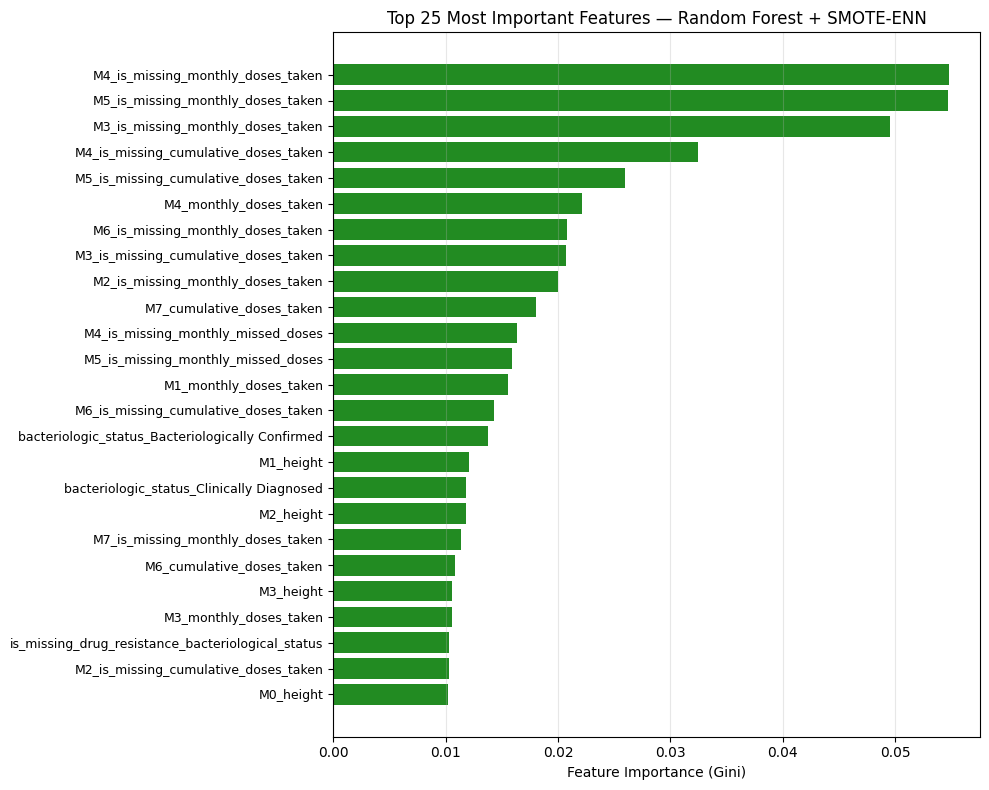


Feature importance by category:
  Static (baseline)             : 0.1681 (16.8%)
  Temporal (raw monthly)        : 0.8256 (82.6%)
  Aggregate (mean/std/min/max)  : 0.0062 (0.6%)
  Trend (slopes)                : 0.0001 (0.0%)
  Latest month                  : 0.0000 (0.0%)


In [9]:
# Get feature importance
importances = rf_model.feature_importances_

if len(feature_names_rf) < len(importances):
    feature_names_padded = feature_names_rf + [
        f"pad_{i}" for i in range(len(importances) - len(feature_names_rf))
    ]
else:
    feature_names_padded = feature_names_rf[:len(importances)]

importance_df = pd.DataFrame({
    "feature": feature_names_padded,
    "importance": importances
}).sort_values("importance", ascending=False)

top_n = 25
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(top_n), top_features["importance"].values[::-1], color="forestgreen")
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features["feature"].values[::-1], fontsize=9)
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title(f"Top {top_n} Most Important Features — Random Forest + SMOTE-ENN")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(MODEL_DIR / "rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Categorize feature importance
print("\nFeature importance by category:")
categories = {
    "Static (baseline)": [f for f in importance_df["feature"] if not any(
        f.startswith(p) for p in ["M", "mean_", "std_", "min_", "max_",
                                   "trend_", "latest_", "months_"])],
    "Temporal (raw monthly)": [f for f in importance_df["feature"] if f[:1] == "M" and "_" in f],
    "Aggregate (mean/std/min/max)": [f for f in importance_df["feature"]
                                       if any(f.startswith(p) for p in ["mean_", "std_", "min_", "max_"])],
    "Trend (slopes)": [f for f in importance_df["feature"] if f.startswith("trend_")],
    "Latest month": [f for f in importance_df["feature"] if f.startswith("latest_")],
}

for cat_name, cat_features in categories.items():
    cat_importance = importance_df[importance_df["feature"].isin(cat_features)]["importance"].sum()
    print(f"  {cat_name:<30s}: {cat_importance:.4f} "
          f"({cat_importance / importances.sum() * 100:.1f}%)")

## 7. Per-Month Prediction Accuracy

Evaluate prediction quality at each month M0–M12 across all test patients.

Per-month — Random Forest + SMOTE-ENN (threshold=0.67):
month  accuracy       f1  balanced_accuracy  specificity      auc  n_correct  n_total
   M0  0.613636 0.721311           0.706140     0.833333 0.855263         27       44
   M1  0.818182 0.885714           0.824561     0.833333 0.872807         36       44
   M2  0.818182 0.885714           0.824561     0.833333 0.885965         36       44
   M3  0.840909 0.901408           0.837719     0.833333 0.894737         37       44
   M4  0.818182 0.888889           0.754386     0.666667 0.916667         36       44
   M5  0.863636 0.916667           0.850877     0.833333 0.951754         38       44
   M6  0.931818 0.960000           0.890351     0.833333 0.951754         41       44
   M7  0.931818 0.960000           0.890351     0.833333 0.960526         41       44
   M8  0.931818 0.960000           0.890351     0.833333 0.964912         41       44
   M9  0.931818 0.960000           0.890351     0.833333 0.973684         41       4

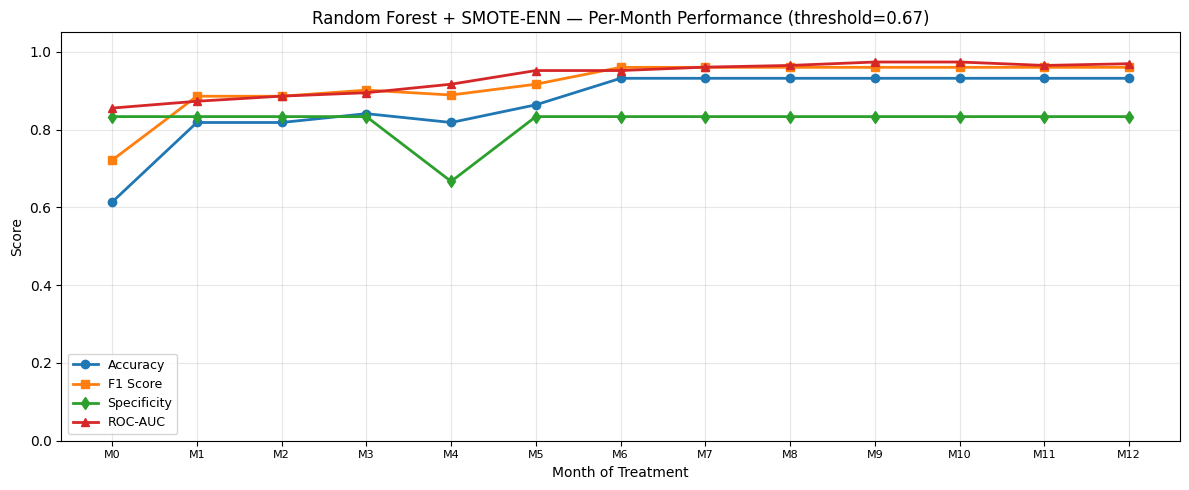

In [10]:
test_temporal = X_temporal[test_idx]
test_static = X_static[test_idx]
test_labels = y[test_idx]

rf_monthly = evaluate_per_month(
    rf_model, test_temporal, test_static, test_labels,
    temporal_names, static_names, n_features_full,
    threshold=optimal_threshold,
)

print(f"Per-month — Random Forest + SMOTE-ENN (threshold={optimal_threshold:.2f}):")
print(rf_monthly.to_string(index=False))

# Plot per-month performance
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(13), rf_monthly["accuracy"], "o-", label="Accuracy", linewidth=2)
ax.plot(range(13), rf_monthly["f1"], "s-", label="F1 Score", linewidth=2)
ax.plot(range(13), rf_monthly["specificity"], "d-", label="Specificity", linewidth=2)
ax.plot(range(13), rf_monthly["auc"], "^-", label="ROC-AUC", linewidth=2)
ax.set_xlabel("Month of Treatment")
ax.set_ylabel("Score")
ax.set_title(f"Random Forest + SMOTE-ENN — Per-Month Performance (threshold={optimal_threshold:.2f})")
ax.set_xticks(range(13))
ax.set_xticklabels([f"M{i}" for i in range(13)], fontsize=8)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(MODEL_DIR / "rf_per_month_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Cross-Validation (Robustness Check)

Stratified 5-fold cross-validation provides a more robust estimate of model performance with only 205 patients.

In [11]:
# Build full M12 features for all patients
X_all_full, _ = build_features_at_month(
    X_temporal, X_static, up_to_month=12,
    temporal_names=temporal_names, static_names=static_names
)

cv_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring_metrics = ["balanced_accuracy", "f1", "roc_auc", "precision", "recall"]
print("5-Fold Stratified Cross-Validation Results (M12 features):")
print("-" * 55)

cv_results = {}
for metric in scoring_metrics:
    scores = cross_val_score(cv_model, X_all_full, y, cv=cv, scoring=metric)
    cv_results[metric] = scores
    print(f"  {metric:<12s}: {scores.mean():.4f} ± {scores.std():.4f}  "
          f"(folds: {', '.join(f'{s:.3f}' for s in scores)})")

5-Fold Stratified Cross-Validation Results (M12 features):
-------------------------------------------------------
  balanced_accuracy: 0.8819 ± 0.0589  (folds: 0.871, 0.855, 0.890, 0.986, 0.808)
  f1          : 0.9676 ± 0.0099  (folds: 0.966, 0.959, 0.959, 0.986, 0.967)
  roc_auc     : 0.9542 ± 0.0424  (folds: 0.887, 0.922, 0.984, 0.996, 0.982)
  precision   : 0.9655 ± 0.0209  (folds: 0.960, 0.959, 0.972, 1.000, 0.936)
  recall      : 0.9702 ± 0.0179  (folds: 0.973, 0.959, 0.946, 0.973, 1.000)


## 9. Export to ONNX and ORT

Export the trained Random Forest model to ONNX and ORT formats for web browser deployment.


In [12]:
# Reload model_utils to get the updated export function
import importlib
import sys
if 'model_utils' in sys.modules:
    del sys.modules['model_utils']

from model_utils import export_tree_model_to_onnx

# Prepare dummy sample for ONNX validation
X_dummy, _ = build_features_at_month(
    X_temporal[:1], X_static[:1], up_to_month=12,
    temporal_names=temporal_names, static_names=static_names
)

# Export to ONNX and ORT
print(f"\n{'='*55}")
print(f"  Exporting Random Forest Model to ONNX/ORT")
print(f"{'='*55}")

export_result = export_tree_model_to_onnx(
    fitted_pipeline=rf_model,
    feature_names=feature_names_rf,
    model_name="random_forest_temporal",
    output_dir=MODEL_DIR,
    X_dummy_sample=X_dummy,
)

if export_result['onnx_path']:
    print(f"✓ ONNX: {export_result['onnx_path']}")
    print(f"✓ ORT:  {export_result['ort_path']}")
    print(f"✓ Features: {len(export_result['feature_names'])} dimensions")
    
    # Quick verification: load ONNX and test inference
    import onnxruntime as ort
    
    # Use ONNX file directly (ORT file might have format differences)
    onnx_model_path = export_result['onnx_path']
    try:
        ort_session = ort.InferenceSession(
            str(onnx_model_path),
            providers=['CPUExecutionProvider']
        )
        
        # Test with dummy batch
        X_test_batch = X_dummy[:5].astype(np.float32)
        input_name = ort_session.get_inputs()[0].name
        ort_inputs = {input_name: X_test_batch}
        ort_outputs = ort_session.run(None, ort_inputs)
        ort_probs = ort_outputs[0]
        
        print(f"\n✓ ONNX Inference Verification:")
        print(f"  Input shape:  {X_test_batch.shape}")
        print(f"  Output shape: {ort_probs.shape}")
        print(f"  Sample predictions: {ort_probs[:3].flatten()}")
        print(f"  Output range: [{ort_probs.min():.4f}, {ort_probs.max():.4f}]")
        print(f"\n✓ Model is ready for web deployment")
        print(f"  Use .onnx file with ONNX Runtime in browser or Node.js")
    except Exception as e:
        print(f"\n⚠ Inference test failed: {type(e).__name__}: {str(e)[:100]}")
        print(f"  ONNX file is still valid, may be format/provider issue")
else:
    print(f"✗ ONNX export failed — Using joblib checkpoint instead")
    if 'checkpoint_path' in export_result and export_result['checkpoint_path']:
        print(f"✓ Model checkpoint available: {export_result['checkpoint_path']}")
        print(f"\nFor web deployment:")
        print(f"  Use: model = joblib.load('{export_result['checkpoint_path']}')")
        print(f"  Then: probs = model.predict_proba(X)")
        print(f"  Or use Node.js with Python subprocess to call the model")


  Exporting Random Forest Model to ONNX/ORT
Converting random_forest_temporal to ONNX (detected: RandomForestClassifier from sklearn.ensemble._forest)...
  Using skl2onnx for RandomForestClassifier conversion...
✓ ONNX model saved: random_forest_temporal.onnx
Verifying ONNX model...
✓ ONNX model verified (output shape: (1,))
✓ ORT model saved: random_forest_temporal.ort
✓ ONNX: c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\models\Temporal\v2\output\random_forest\random_forest_temporal.onnx
✓ ORT:  c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\models\Temporal\v2\output\random_forest\random_forest_temporal.ort
✓ Features: 399 dimensions

✓ ONNX Inference Verification:
  Input shape:  (1, 399)
  Output shape: (1,)
  Sample predictions: [1]
  Output range: [1.0000, 1.0000]

✓ Model is ready for web deployment
  Use .onnx file with ONNX Runtime in browser or Node.js


## 9. Save Model Config & Evaluation Report

In [13]:
# ── Save model config ────────────────────────────────────────────
config = {
    "model": "Random Forest + SMOTE-ENN",
    "augmentation": "SMOTE-ENN (Synthetic Minority Oversampling + Edited Nearest Neighbors)",
    "random_forest_params": {
        "n_estimators": 500, "max_depth": 8, "min_samples_split": 5,
        "min_samples_leaf": 3, "max_features": "sqrt",
        "class_weight": "balanced",
    },
    "n_features": int(n_features_full),
    "n_patients": int(len(y)),
    "train_patients": int(len(train_idx)),
    "val_patients": int(len(val_idx)),
    "test_patients": int(len(test_idx)),
    "training_mode": "progressive_temporal (one sample per patient per month, M0-M12)",
    "split": "70/20/10 (patient-level, stratified)",
    "seed": SEED,
    "feature_policy_version": FEATURE_POLICY_VERSION,
    "dropped_feature_cols": DROPPED_FEATURE_COLS,
    "static_mnar_indicator_count": len(STATIC_MNAR_INDICATORS),
    "temporal_mnar_indicator_count": len(TEMPORAL_MNAR_INDICATORS),
    "threshold": float(optimal_threshold),
    "oob_score": float(rf_model.oob_score_),
}
with open(MODEL_DIR / "rf_model_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("✓ models/rf_model_config.json")

# ── Save evaluation report ──────────────────────────────────────
report_lines = [
    "TB-DOTS CAR CDSS — Random Forest Evaluation Report",
    "=" * 60,
    f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    f"Dataset: {len(y)} patients, split 70/20/10 (patient-level, stratified)",
    f"Training mode: Progressive temporal — 13 samples/patient (M0..M12)",
    f"Features: {n_features_full} (static + engineered temporal)",
    f"Augmentation: SMOTE-ENN",
    f"Optimal threshold: {optimal_threshold:.2f}",
    f"OOB Score: {rf_model.oob_score_:.4f}",
    "",
    f"{'='*55}",
    f"  Test Set Evaluation",
    f"{'='*55}",
]
for k, v in rf_metrics.items():
    report_lines.append(f"  {k:<14s} : {v:.4f}")
report_lines.extend([
    "",
    "Confusion Matrix:",
    str(rf_cm),
    "",
    "Per-Month Performance:",
    "-" * 40,
    rf_monthly.to_string(index=False),
    "",
    "5-Fold Cross-Validation:",
    "-" * 40,
])
for metric, scores in cv_results.items():
    report_lines.append(f"  {metric:<12s}: {scores.mean():.4f} ± {scores.std():.4f}")

with open(MODEL_DIR / "rf_evaluation_report.txt", "w") as f:
    f.write("\n".join(report_lines))
print("✓ models/rf_evaluation_report.txt")

# ── Save metrics JSON for cross-notebook comparison ─────────────
rf_metrics_export = {k: float(v) for k, v in rf_metrics.items()}
rf_metrics_export["threshold"] = float(optimal_threshold)
rf_metrics_export["oob_score"] = float(rf_model.oob_score_)
with open(MODEL_DIR / "rf_metrics.json", "w") as f:
    json.dump(rf_metrics_export, f, indent=2)
print("✓ models/rf_metrics.json")

print("\nAll saved files:")
print("  ✓ models/rf_smoteenn_model.pkl")
print("  ✓ models/rf_model_config.json")
print("  ✓ models/rf_evaluation_report.txt")
print("  ✓ models/rf_metrics.json")
print("  ✓ models/rf_evaluation_plots.png")
print("  ✓ models/rf_feature_importance.png")
print("  ✓ models/rf_per_month_performance.png")

✓ models/rf_model_config.json
✓ models/rf_evaluation_report.txt
✓ models/rf_metrics.json

All saved files:
  ✓ models/rf_smoteenn_model.pkl
  ✓ models/rf_model_config.json
  ✓ models/rf_evaluation_report.txt
  ✓ models/rf_metrics.json
  ✓ models/rf_evaluation_plots.png
  ✓ models/rf_feature_importance.png
  ✓ models/rf_per_month_performance.png
